## Data Processing

### Setup

In [7]:
import os
import multiprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import transforms

import nibabel as nib
import albumentations as alb

In [8]:
seed = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### Data Paths

In [43]:
def create_dataset_path_df(dataset_dir):
    flair_suffix = "flair.nii.gz"
    t1_suffix = "t1.nii.gz"
    t1ce_suffix = "t1ce.nii.gz"
    t2_suffix = "t2.nii.gz"
    seg_suffix = "seg.nii.gz"
    dataset_dict = {
                    'directory_path':[],
                    'flair_path':[],
                    't1_path':[],
                    't1ce_path':[],
                    't2_path':[],
                    'seg_path':[]
                    }
    missing_flair = 0
    missing_t1 = 0
    missing_t1ce = 0
    missing_t2 = 0
    missing_seg = 0
    missing_files_dirs = []
    for dir in os.listdir(dataset_dir):
        dir_path = os.path.join(dataset_dir,dir)
        if not os.path.isdir(dir_path) or not dir.startswith('BraTS2021'):
            continue
        dataset_dict['directory_path'].append(dir_path)
        
        flair_found = t1_found = t1ce_found = t2_found = seg_found = False
        for image in os.listdir(dir_path):
            image_path = os.path.join(dir_path, image)

            if image.endswith(flair_suffix):
                dataset_dict['flair_path'].append(image_path)
                flair_found = True
            elif image.endswith(t1_suffix):
                dataset_dict['t1_path'].append(image_path)
                t1_found = True
            elif image.endswith(t1ce_suffix):
                dataset_dict['t1ce_path'].append(image_path)
                t1ce_found = True
            elif image.endswith(t2_suffix):
                dataset_dict['t2_path'].append(image_path)
                t2_found = True
            elif image.endswith(seg_suffix):
                dataset_dict['seg_path'].append(image_path)
                seg_found = True

        if not flair_found:
            dataset_dict['flair_path'].append(None)
            missing_flair += 1
        if not t1_found:
            dataset_dict['t1_path'].append(None)
            missing_t1 += 1
        if not t1ce_found:
            dataset_dict['t1ce_path'].append(None)
            missing_t1ce += 1
        if not t2_found:
            dataset_dict['t2_path'].append(None)
            missing_t2 += 1
        if not seg_found:
            dataset_dict['seg_path'].append(None)
            missing_seg += 1
        if flair_found or t1_found or t1ce_found or t2_found or seg_found:
            pass
        else:
            missing_files_dirs.append(dir_path)
    print(f"Total missing files:")
    print(f"  - Flair: {missing_flair}")
    print(f"  - T1: {missing_t1}")
    print(f"  - T1ce: {missing_t1ce}")
    print(f"  - T2: {missing_t2}")
    print(f"  - Seg: {missing_seg}")
    print(f"Missing files at: {missing_files_dirs}")
    return pd.DataFrame(dataset_dict)

    return dataset_dict
dataset_dir = "../data/brats2021"
dataset = create_dataset_path_df(dataset_dir)
dataset.head()

Total missing files:
  - Flair: 0
  - T1: 0
  - T1ce: 0
  - T2: 0
  - Seg: 0
Missing files at: []


,directory_path,flair_path,t1_path,t1ce_path,t2_path,seg_path
0,../data/brats2021\BraTS2021_01163,../data/brats2021\BraTS2021_01163\BraTS2021_01...,../data/brats2021\BraTS2021_01163\BraTS2021_01...,../data/brats2021\BraTS2021_01163\BraTS2021_01...,../data/brats2021\BraTS2021_01163\BraTS2021_01...,../data/brats2021\BraTS2021_01163\BraTS2021_01...
1,../data/brats2021\BraTS2021_01163_10,../data/brats2021\BraTS2021_01163_10\BraTS2021...,../data/brats2021\BraTS2021_01163_10\BraTS2021...,../data/brats2021\BraTS2021_01163_10\BraTS2021...,../data/brats2021\BraTS2021_01163_10\BraTS2021...,../data/brats2021\BraTS2021_01163_10\BraTS2021...
2,../data/brats2021\BraTS2021_01163_2,../data/brats2021\BraTS2021_01163_2\BraTS2021_...,../data/brats2021\BraTS2021_01163_2\BraTS2021_...,../data/brats2021\BraTS2021_01163_2\BraTS2021_...,../data/brats2021\BraTS2021_01163_2\BraTS2021_...,../data/brats2021\BraTS2021_01163_2\BraTS2021_...
3,../data/brats2021\BraTS2021_01163_3,../data/brats2021\BraTS2021_01163_3\BraTS2021_...,../data/brats2021\BraTS2021_01163_3\BraTS2021_...,../data/brats2021\BraTS2021_01163_3\BraTS2021_...,../data/brats2021\BraTS2021_01163_3\BraTS2021_...,../data/brats2021\BraTS2021_01163_3\BraTS2021_...
4,../data/brats2021\BraTS2021_01163_4,../data/brats2021\BraTS2021_01163_4\BraTS2021_...,../data/brats2021\BraTS2021_01163_4\BraTS2021_...,../data/brats2021\BraTS2021_01163_4\BraTS2021_...,../data/brats2021\BraTS2021_01163_4\BraTS2021_...,../data/brats2021\BraTS2021_01163_4\BraTS2021_...


In [44]:
train_size = 0.8
val_size = 0.1
test_size = 0.1
random_state = 42
dataset_train, temp = train_test_split(dataset, test_size = val_size+test_size, random_state = random_state)
dataset_val, dataset_test = train_test_split(temp, test_size = test_size / (val_size + test_size), random_state = random_state)
print(f"Train set shape: {dataset_train.shape}")
print(f"Validation set shape: {dataset_val.shape}")
print(f"Test set shape: {dataset_test.shape}")

Train set shape: (8, 6)
Validation set shape: (1, 6)
Test set shape: (1, 6)


### Custom Dataset Class

In [76]:
class BrainTumorDataset(Dataset):
    def __init__(self, datapath_df, upper_bound=100, lower_bound=60, window_size = 3, transforms=None):
        self._datapath_df = datapath_df
        self.upper_bound = upper_bound
        self.lower_bound = lower_bound
        self.window_size = window_size
        self.transforms = transforms

    def __len__(self):
        return self._datapath_df.shape[0]

    def _normalize_data(self, volume):
        mean = np.mean(volume)
        if mean==0:
            mean = 1
        std = np.std(volume)
        return (volume-mean)/std

    def _get_adjacent_slices(self, data, mask):
        # Return data: [Height x Width x (Modalities*window_size), ] * (Depth-window_size+1), 
        # Return mask: [Height x Width] * (Depth-window_size+1)
        #data = [data[:,:,:,i].transpose(1,2,0) for i in range(max(self.lower_bound,0), min(self.upper_bound,data.shape[-1]))]
        #mask = [mask[:,:,i] for i in range(max(self.lower_bound,0), min(self.upper_bound,mask.shape[-1]))]
        slice_groups = []
        mask_slices = []

        depth = data.shape[-1]
        start = max(self.lower_bound, 0)
        end = min(self.upper_bound, depth)

        for i in range(start, end - self.window_size + 1):
            slice_group = np.stack([data[:, :, :, j] for j in range(i, i + self.window_size)], axis=1)
            slice_groups.append(slice_group)
            mask_slices.append(mask[:, :, i + self.window_size // 2])

        # Convert to Numpy arrays: [
        slices_np = np.stack(slice_groups, axis=0)
        masks_np = np.stack(mask_slices, axis=0)

        # Convert to tensors
        slices = torch.tensor(slices_np, dtype=torch.float32)
        masks = torch.tensor(masks_np, dtype=torch.float32)

        return slices, masks

    # def _apply_transforms(self, data, mask):
    #     print(data.shape)
    #     print(mask.shape)
    #     if self.transforms:
    #         spatial_transforms = self.transforms.get('spatial_transforms',None)
    #         intensity_transforms = self.transforms.get('intensity_transforms',None)
    #
    #         if spatial_transforms:
    #             for i in range(len(data)):
    #                 augmented_data = spatial_transforms(image=data[i])
    #
    #                 data[i] = augmented_data["image"]
    #         if intensity_transforms:
    #             for i in range(len(data)):
    #                 augmented_data = intensity_transforms(image=data[i])
    #                 data[i] = augmented_data["image"]
    #
    #     return data, mask
    def _apply_transforms(self, data, mask):
        if self.transforms:
            spatial_transforms = self.transforms.get('spatial_transforms', None)
            intensity_transforms = self.transforms.get('intensity_transforms', None)

            for i in range(data.shape[-1]):
                image_slice = data[:, :, :, i].astype(np.float32)  # Ensure float32 for image
                mask_slice = mask[:, :, i].astype(np.uint8)  # Ensure uint8 for mask

                # Transpose image slice to [H, W, Modality] for albumentations
                image_slice = image_slice.transpose(1, 2, 0)  # [H, W, Modality]
                mask_slice = mask_slice[..., None]  # Add channel to mask → [H, W, 1]

                if spatial_transforms:
                    augmented = spatial_transforms(image=image_slice, mask=mask_slice)
                    image_slice = augmented["image"]
                    mask_slice = augmented["mask"]

                if intensity_transforms:
                    augmented = intensity_transforms(image=image_slice)
                    image_slice = augmented["image"]

                # Transpose back to original shape
                data[:, :, :, i] = image_slice.transpose(2, 0, 1).astype(np.float32)  # Back to [Modality, H, W]
                mask[:, :, i] = mask_slice.squeeze(-1).astype(np.uint8)  # Remove channel dim and convert to uint8

        return data, mask

    def __getitem__(self, index):
        data = []
        row = self._datapath_df.iloc[index]
        data.append(self._normalize_data(nib.load(row.flair_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t1_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t1ce_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t2_path).get_fdata()))
        data = np.stack(data, axis=0)

        mask = nib.load(row.seg_path).get_fdata()
        data, mask = self._apply_transforms(data, mask)
        data, mask = self._get_adjacent_slices(data, mask) 
        len(data)
            
        return data, mask

### Transforms

| **Augmentation**    | **Function**                                                                                             | **Reasoning**                                                                                                                                       |
|-------------------------------|-------------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Horizontal Flip               | Randomly flips the image horizontally.                                                                                 | Increases training data diversity; however, caution is needed because brain hemispheres can be lateralized, and tumors may show a side-specific distribution.    |
| Rotation                      | Rotates the image by a small angle (±5°).                                                                               | Mimics slight head tilts during MRI acquisition, helping the model learn minor orientation variations without distorting anatomical structures.                  |
| Random Scale                  | Scales the image by a factor within ±8%.                                                                               | Simulates variations in scanner zoom or patient size while preserving the relative sizes of brain structures and tumor-to-brain ratios.                             |
| Elastic Transform             | Applies smooth, local deformations to the image.                                                                       | Mimics realistic soft-tissue deformations in MR images; careful parameter tuning prevents unrealistic warping of critical tumor morphology.                       |
| Affine Transform              | Performs minor translations, rotations, and scaling simultaneously.                                                  | Adjusts for slight differences in patient positioning; maintains anatomical consistency while introducing subtle spatial variability.                           |
| Pad & Resize                  | Pads the image (if necessary) and resizes it to a fixed dimension (e.g., 240×240).                                      | Ensures uniform input dimensions for the network, which is vital for consistent performance and accurate segmentation.                                             |
| Random Brightness/Contrast    | Adjusts brightness and contrast within a moderate range (±15%).                                                        | Reflects variations in imaging conditions and scanner calibration while preserving subtle tumor intensity differences critical for segmentation.                |
| GaussNoise                    | Adds Gaussian noise with moderate variance.                                                                          | Emulates scanner noise found in real MR images, which helps the model become robust to noise without masking important details of tumor boundaries.             |
| Random Gamma Correction       | Modifies the image gamma within a narrow range (98–102).                                                               | Maintains clinically relevant intensity distributions and preserves tumor contrast, ensuring that subtle intensity variations remain interpretable.              |
| Median Blur                   | Applies a slight blur to reduce noise while preserving edges.                                                        | Helps in reducing high-frequency noise and artifacts without losing the sharp boundaries needed for precise delineation of tumor margins.                         |


In [46]:
transforms = {}
spatial_transforms = alb.Compose([
    alb.HorizontalFlip(p=0.3),
    alb.Rotate(limit=5, p=0.3),
    alb.RandomScale(scale_limit=0.08, p=0.3),
    alb.ElasticTransform(alpha=1, sigma=2.5, p=0.2),
    alb.Affine(scale=(0.95, 1.05), translate_percent=(0.02, 0.02), rotate=(-5, 5), p=0.3, fit_output=False),
    # alb.PadIfNeeded(min_height=256, min_width=256),
    alb.PadIfNeeded(min_height=240, min_width=240),
    # alb.Resize(256, 256)
    alb.Resize(240, 240)
], additional_targets={"mask":"mask"})
intensity_transforms = alb.Compose([
    alb.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
    alb.GaussNoise(p=0.3),
    alb.RandomGamma(gamma_limit=(98,102), p=0.3),
    alb.MedianBlur(blur_limit=3, p=0.2),
])
transforms['spatial_transforms'] = spatial_transforms
transforms['intensity_transforms'] = intensity_transforms

In [77]:
upper_bound=100
lower_bound=60 
window_size = 3
test_data = BrainTumorDataset(dataset_test,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transforms=transforms)
data, mask = test_data[0]
print(f"Number of Datapoints: {len(data)}")
print(f"Data Shape: {data[0].shape}")
print(f"Mask Shape: {mask[0].shape}")

C:\Users\mk366\miniconda3\envs\BTSeg\Lib\site-packages\albumentations\augmentations\functional.py:1128: RuntimeWarning: invalid value encountered in power
  return np.power(img, gamma)
C:\Users\mk366\miniconda3\envs\BTSeg\Lib\site-packages\albucore\utils.py:108: RuntimeWarning: invalid value encountered in cast
  return np.clip(img, 0, max_value).astype(dtype)


Number of Datapoints: 38
Data Shape: torch.Size([4, 3, 240, 240])
Mask Shape: torch.Size([240, 240])


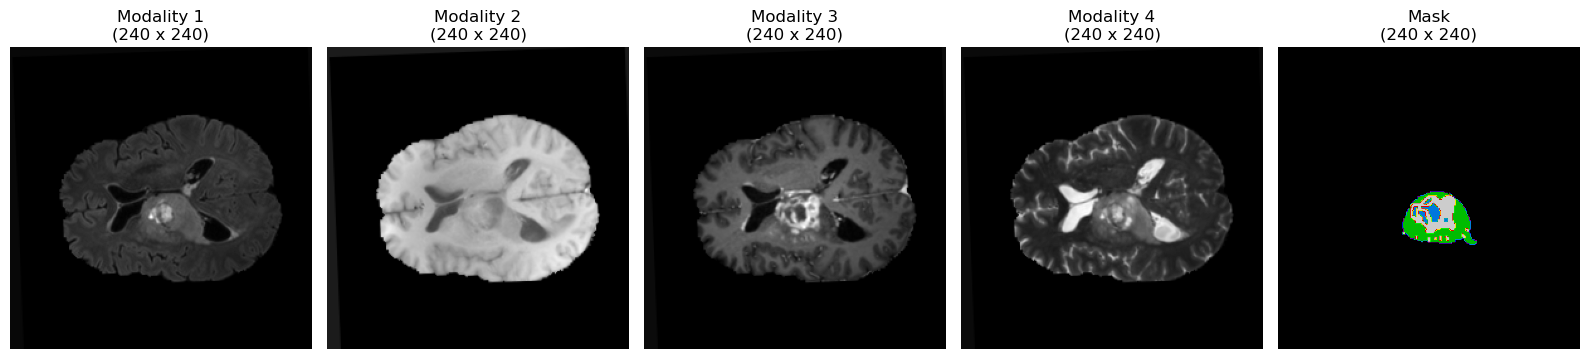

In [106]:
# idx = np.random.randint(upper_bound-lower_bound)
#
# plt.figure(figsize=(15,15))
#
# for i in range(data[idx].shape[-1]):
#     plt.subplot(4,4,i+1)
#     print(data[idx][1].shape)
#     plt.imshow(data[idx][1][:,:], cmap="gray")
#     plt.title("Data")
#
# plt.subplot(4,4,i+2)
# plt.imshow(mask[idx], cmap="nipy_spectral")
# plt.title("Mask")

batch_idx = np.random.randint(data.shape[0])

plt.figure(figsize=(16, 8))

# Plot all 4 modalities
for i in range(4):
    plt.subplot(1, 5, i + 1)  # Create a 1x5 grid of plots
    plt.imshow(data[batch_idx, i, 1, :, :], cmap="gray")
    h, w = data[batch_idx, i, 1].shape
    plt.title(f"Modality {i + 1}\n({h} x {w})")
    plt.axis("off")

# Plot the corresponding mask for the same slice
plt.subplot(1, 5, 5)
plt.imshow(mask[batch_idx,:, :], cmap="nipy_spectral")
h, w = mask[batch_idx].shape
plt.title(f"Mask\n({h} x {w})")
plt.axis("off")

plt.tight_layout()
plt.show()

### Dataloader

In [40]:
upper_bound=100
lower_bound=60 
window_size = 3
train_data = BrainTumorDataset(dataset_train,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transforms=transforms)
val_data = BrainTumorDataset(dataset_val,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transforms=transforms)
test_data = BrainTumorDataset(dataset_test,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transforms=transforms)
pd.Series({
    'Training dataset size:': len(train_data),
    'Validation dataset size:': len(val_data),
    'Testing dataset size:': len(test_data)
}).to_frame().style.hide(axis='columns')

Training dataset size:,300
Validation dataset size:,38
Testing dataset size:,38


In [42]:
def collate_fn(batch):
    data = []
    mask = []
    for X, label in batch:
        data.extend(X)
        mask.extend(label)
    data = np.array(data)
    mask = np.array(mask)
    data = torch.tensor(data, dtype=torch.float32)
    mask = torch.tensor(mask, dtype=torch.float32)
    return data, mask

per_datapoint_batch_size = (upper_bound-lower_bound)-window_size+1
batch_size_multiplication_factor = 2
batch_size = int(per_datapoint_batch_size*batch_size_multiplication_factor)
num_workers = multiprocessing.cpu_count()//2
num_workders = -1
persistent_workers = True
pin_memory = True if device=='cuda' else False
pin_memory_device = device
data_loader_params = {
    'batch_size': batch_size_multiplication_factor,
    'num_workers': num_workers,
    'persistent_workers': persistent_workers,
    'pin_memory': pin_memory,
    'pin_memory_device': pin_memory_device,
    'collate_fn': collate_fn,
}
print(f'Number of datapoints per batch {batch_size}')
train_dataloader = DataLoader(train_data, **data_loader_params, shuffle=True)
val_dataloader = DataLoader(val_data, **data_loader_params)
test_dataloader = DataLoader(test_data, **data_loader_params)

Number of datapoints per batch 76


In [43]:
pd.Series({
    'Number of batches in train dataLoader:': len(train_dataloader),
    'Number of batches in validation dataLoader:': len(val_dataloader),
    'Number of batches in test dataLoader:': len(test_dataloader)
}).to_frame().style.hide(axis='columns')

Number of batches in train dataLoader:,150
Number of batches in validation dataLoader:,19
Number of batches in test dataLoader:,19


In [44]:
for batch_idx, (data, mask) in enumerate(train_dataloader):
    print(f"Batch {batch_idx}:")
    print(f"  Data shape: {data.shape}")
    print(f"  Mask shape: {mask.shape}")
    break

Batch 0:
  Data shape: torch.Size([76, 240, 240, 12])
  Mask shape: torch.Size([76, 240, 240])


## Model Training

### Setup

In [43]:
import torch
import segmentation_models_pytorch as smp
from monai.networks.nets import AttentionUnet as MAttentionUnet
from monai.networks.nets import UNETR

### Model Instantiation

#### UNETR

In [41]:
class UNETR_V0(torch.nn.Module):
    def __init__(self,):
        super(UNETR_V0, self).__init__()
        self.unetr = UNETR(
                            in_channels=4,       # Number of input channels (modalities) → T1, T2, FLAIR, T1ce
                            out_channels=4,      # Number of output segmentation classes (1 = binary, >1 = multi-class)
                            
                            img_size=(16, 240, 240),  # Input size → (Depth slices, Height, Width)
                            # patch_size=(1, 16, 16), # Visual token size
                            
                            feature_size=16,     # Base feature size of the encoder (affects transformer token dimensions)
                            hidden_size=768,     # Transformer hidden size (same as ViT/UNETR)
                            mlp_dim=3072,        # MLP feed-forward layer dimension (typically 4×hidden_size)
                            
                            num_heads=12,        # Number of self-attention heads in transformer blocks (higher = more expressive)
                            proj_type="perceptron",  # Type of projection (alternative is "conv" for convolutional projection)
                            
                            norm_name="instance", # Type of normalization → "instance" (better for medical images) or "batch"
                            res_block=True,      # Use residual connections in CNN decoder blocks (helps gradient flow)
                            
                            dropout_rate=0.1,    # Dropout applied in transformer layers (0.0 = no dropout, useful in small datasets)
                        )
    def forward(self, X):
        X = self.unetr(X)
        return X

In [42]:
dummy_input = torch.randn((2, 4, 16, 240, 240))
unetr = UNETR_V0().to('cuda')
dummy_output = unetr(dummy_input.to('cuda'))
dummy_output.shape

torch.Size([2, 4, 16, 240, 240])

Conclusion
- Model is too big for 12G GPU.
- UNETR can't process depth of 3. It has to be larger >=16

Resolution
- UNET for 2D segmention where modalities and depth are combined.
- Add attention to get optimal weightage.

#### UNET With Merged Modalities & Depth - Attention, No residuals.

In [5]:
class UNET_V0(torch.nn.Module):
    def __init__(self,):
        super(UNET_V0, self).__init__()
        self.unet = MAttentionUnet(
                        spatial_dims=2,       # Specifies a 2D UNet (for slice-wise medical image segmentation)
                        in_channels=12,       # Number of input channels (e.g., multi-modal MRI with 12 input features)
                        out_channels=4,       # Number of output channels (multi-class segmentation with 4 classes)
                        channels=(16, 32, 64, 128),  # Number of feature maps at each level of the UNet
                        strides=(2, 2, 2, 2),  # Down-sampling factor at each level of the encoder (reduces spatial size)
                        kernel_size=3,        # Convolution kernel size
                        up_kernel_size=3,     # Kernel size for upsampling layers
                        dropout=0.1,          # Dropout rate for regularization (optional)
                    )

    def forward(self, X):
        X = self.unet(X)
        return X

In [6]:
dummy_input = torch.randn((2, 12, 240, 240))
unet = UNET_V0().to('cuda')
dummy_output = unet(dummy_input.to('cuda'))
dummy_output.shape

torch.Size([2, 4, 240, 240])

#### UNET With Merged Modalities & Depth - Pretrained Weight + Residuals + Attention (Only 2D)

In [10]:
class UNET_V1(torch.nn.Module):
    def __init__(self,):
        super(UNET_V1, self).__init__()
        self.unet = smp.Unet(
                    encoder_name="resnet50",        # Encoder: resnet34/ efficientnet-b0 / resnet50
                    encoder_weights="imagenet",     # Pre-trained on ImageNet
                    in_channels=12,                  # Number of input channels (e.g., RGB images)
                    classes=4,                      # Number of segmentation classes
                    activation="softmax2d",         # Multi-class segmentation requires softmax activation
                    decoder_attention_type="scse",  # Spatial and Channel Squeeze & Excitation (SCSE) attention
                )

    def forward(self, X):
        X = self.unet(X)
        return X

In [12]:
dummy_input = torch.randn((2, 12, 256, 256))
unet = UNET_V1().to('cuda')
dummy_output = unet(dummy_input.to('cuda'))
dummy_output.shape

torch.Size([2, 4, 256, 256])

#### UNET++ With Merged Modalities & Depth - Pretrained Weight + Residuals + Attention (Only 2D)

In [44]:
class UNET_V2(torch.nn.Module):
    def __init__(self,):
        super(UNET_V2, self).__init__()
        self.unet = smp.UnetPlusPlus(
                    encoder_name="resnet50",        # Encoder: resnet34/ efficientnet-b0 / resnet50
                    encoder_weights="imagenet",     # Pre-trained on ImageNet
                    in_channels=12,                  # Number of input channels (e.g., RGB images)
                    classes=4,                      # Number of segmentation classes
                    activation="softmax2d",         # Multi-class segmentation requires softmax activation
                    decoder_attention_type="scse",  # Spatial and Channel Squeeze & Excitation (SCSE) attention
                )

    def forward(self, X):
        X = self.unet(X)
        return X

In [45]:
dummy_input = torch.randn((2, 12, 256, 256))
unet = UNET_V2().to('cuda')
dummy_output = unet(dummy_input.to('cuda'))
dummy_output.shape

torch.Size([2, 4, 256, 256])

#### UNET With Depth - Attention, No residuals.

In [46]:
class UNET_V3(torch.nn.Module):
    def __init__(self,):
        super(UNET_V3, self).__init__()
        self.unet = MAttentionUnet(
                        spatial_dims=3,       # Specifies a 2D UNet (for slice-wise medical image segmentation)
                        in_channels=4,       # Number of input channels (e.g., multi-modal MRI with 12 input features)
                        out_channels=4,       # Number of output channels (multi-class segmentation with 4 classes)
                        channels=(16, 32, 64, 128),  # Number of feature maps at each level of the UNet
                        strides=(1, 1, 1, 2),  # Down-sampling factor at each level of the encoder (reduces spatial size)
                        kernel_size=3,        # Convolution kernel size
                        up_kernel_size=3,     # Kernel size for upsampling layers
                        dropout=0.1,          # Dropout rate for regularization (optional)
                    )

    def forward(self, X):
        X = self.unet(X)
        return X

In [47]:
dummy_input = torch.randn((2, 4, 3, 240, 240))
unet = UNET_V3().to('cuda')
dummy_output = unet(dummy_input.to('cuda'))
dummy_output.shape

torch.Size([2, 4, 3, 240, 240])

In [15]:
# Discard 0 and 2, propogate loss for only 1
dummy_output[:,:,1,:,:] # torch.Size([2, 4, 240, 240])
torch.argmax(dummy_output[:,:,1,:,:], dim=1) # torch.Size([2, 240, 240])
print()